# ECG data exploration for cardiac arrhythmia

This notebook explores the PTB-XL ECG data stored in `../data`. The focus is on understanding the label space and feature distributions before training a model for cardiac arrhythmia detection/classification.

In [1]:
from pathlib import Path
import ast
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
DATASET_DIR = DATA_DIR / "ptb-xl-a-comprehensive-electrocardiographic-feature-dataset-1.0.1"

if not DATASET_DIR.exists():
    candidates = sorted(DATA_DIR.glob("ptb-xl-*"))
    DATASET_DIR = next((p for p in candidates if p.is_dir()), DATASET_DIR)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset dir:  {DATASET_DIR}")
print(f"Dataset exists: {DATASET_DIR.exists()}")

Project root: /Users/gubscruz/INSPER/7_PERIODO/ai-medicine/ecg-anomaly-detection
Dataset dir:  /Users/gubscruz/INSPER/7_PERIODO/ai-medicine/ecg-anomaly-detection/data/ptb-xl-a-comprehensive-electrocardiographic-feature-dataset-1.0.1
Dataset exists: True


## 1. Inventory

Check which parts of the PTB-XL extraction are available locally.

In [2]:
assert DATASET_DIR.exists(), f"Dataset folder not found: {DATASET_DIR}"

files = pd.DataFrame(
    [
        {
            "path": str(path.relative_to(DATASET_DIR)),
            "suffix": path.suffix.lower() or "[no suffix]",
            "size_mb": path.stat().st_size / 1_000_000,
        }
        for path in DATASET_DIR.rglob("*")
        if path.is_file() and path.name != ".DS_Store"
    ]
)

summary = (
    files.groupby("suffix")
    .agg(files=("path", "count"), total_mb=("size_mb", "sum"))
    .sort_values("files", ascending=False)
)
display(summary)
display(files.sort_values("size_mb", ascending=False).head(15))

,files,total_mb
suffix,,
.atr,283332,720.458208
.dat,42708,841.703100
.hea,42708,45.843887
.csv,13,529.158084
.txt,2,43.242874
.py,1,0.011117
[no suffix],1,1.644698


,path,suffix,size_mb
3,features/12sl_features.csv,.csv,93.203750
368761,features/old/12sl_features.csv,.csv,93.203750
368764,features/old/unig_features.csv,.csv,92.217519
6,features/unig_features.csv,.csv,92.217519
5,features/ecgdeli_features.csv,.csv,62.235868
368763,features/old/ecgdeli_features.csv,.csv,62.235832
2,SHA256SUMS.txt,.txt,43.228032
9,labels/12sl_statements.csv,.csv,17.764014
7,labels/ptbxl_statements.csv,.csv,15.938153
0,RECORDS,[no suffix],1.644698


## 2. Load labels and engineered features

The labels live under `labels/`, and the numerical ECG features live under `features/`. `ecg_id` is the join key.

In [3]:
labels_ptbxl = pd.read_csv(DATASET_DIR / "labels" / "ptbxl_statements.csv")
labels_12sl = pd.read_csv(DATASET_DIR / "labels" / "12sl_statements.csv")
snomed = pd.read_csv(DATASET_DIR / "labels" / "snomed_description.csv")

features = {
    "ecgdeli": pd.read_csv(DATASET_DIR / "features" / "ecgdeli_features.csv"),
    "12sl": pd.read_csv(DATASET_DIR / "features" / "12sl_features.csv"),
    "unig": pd.read_csv(DATASET_DIR / "features" / "unig_features.csv"),
}

print("Labels")
print(f"PTB-XL statements: {labels_ptbxl.shape}")
print(f"12SL statements:   {labels_12sl.shape}")
print(f"SNOMED rows:       {snomed.shape}")

print("\nFeature tables")
for name, df in features.items():
    print(f"{name:8s}: {df.shape}")

display(labels_ptbxl.head())
display(labels_12sl.head())

Labels
PTB-XL statements: (21799, 4)
12SL statements:   (21799, 5)
SNOMED rows:       (287, 9)

Feature tables
ecgdeli : (21799, 532)
12sl    : (21799, 783)
unig    : (21795, 749)


,ecg_id,scp_codes,scp_codes_ext,scp_codes_ext_snomed
0,1,"[('NORM', 100.0), ('LVOLT', 100.0), ('SR', 100.0)]","[('NORM', 100.0), ('LVOLT', 100.0), ('SR', 100.0)]","[(320536, 100.0), (441840, 100.0), (4008453, 100.0), (4010019, 100.0), (4021775, 100.0), (4023995, 100.0), (4042140,..."
1,2,"[('NORM', 80.0), ('SBRAD', 100.0)]","[('NORM', 80.0), ('SBRAD', 100.0)]","[(134057, 100.0), (321588, 100.0), (440142, 100.0), (441840, 100.0), (3655971, 100.0), (4008453, 100.0), (4010019, 1..."
2,3,"[('NORM', 100.0), ('SR', 100.0)]","[('NORM', 100.0), ('SR', 100.0)]","[(441840, 100.0), (4008453, 100.0), (4010019, 100.0), (4021775, 100.0), (4023995, 100.0), (4042140, 100.0), (4065279..."
3,4,"[('NORM', 100.0), ('SR', 100.0)]","[('NORM', 100.0), ('SR', 100.0)]","[(441840, 100.0), (4008453, 100.0), (4010019, 100.0), (4021775, 100.0), (4023995, 100.0), (4042140, 100.0), (4065279..."
4,5,"[('NORM', 100.0), ('SR', 100.0)]","[('NORM', 100.0), ('SR', 100.0)]","[(441840, 100.0), (4008453, 100.0), (4010019, 100.0), (4021775, 100.0), (4023995, 100.0), (4042140, 100.0), (4065279..."


,ecg_id,statements,statements_cat,statements_ext,statements_ext_snomed
0,1,"['NSR', 'NML']","['NSR', 'NML']","[('NSR', 100.0), ('NML', 100.0)]","[(441840, 100.0), (4008453, 100.0), (4010019, 100.0), (4021775, 100.0), (4023995, 100.0), (4024571, 100.0), (4042140..."
1,21803,"['SRTH', 'MSAR', 'RBBB', 'IT', 'AB']","['SRTH;MSAR', 'RBBB', 'IT', 'AB']","[('SRTH', 100.0), ('MSAR', 100.0), ('RBBB', 100.0), ('IT', 100.0), ('AB', 100.0)]","[(134057, 100.0), (313791, 100.0), (314059, 100.0), (316999, 100.0), (320425, 100.0), (320536, 100.0), (321588, 100...."
2,21804,"['AFIB', 'RVR', 'RBBB', 'IT', 'AB']","['AFIB;RVR', 'RBBB', 'IT', 'AB']","[('AFIB', 100.0), ('RVR', 100.0), ('RBBB', 100.0), ('IT', 100.0), ('AB', 100.0)]","[(134057, 100.0), (313217, 100.0), (313791, 100.0), (314059, 100.0), (315643, 100.0), (316999, 100.0), (320425, 100...."
3,21805,"['NSR', 'LAD3', 'ASMI', 'AU', 'ST&', 'LT', 'AB']","['NSR', 'LAD3', 'ASMI;AU', 'ST&;LT', 'AB']","[('NSR', 100.0), ('LAD3', 100.0), ('ASMI;AU', 100.0), ('ST&', 100.0), ('LT', 100.0), ('AB', 100.0)]","[(134057, 100.0), (314666, 100.0), (320536, 100.0), (321588, 100.0), (432795, 100.0), (440142, 100.0), (441840, 100...."
4,21806,"['NSR', 'NST', 'AB']","['NSR', 'NST', 'AB']","[('NSR', 100.0), ('NST', 100.0), ('AB', 100.0)]","[(320536, 100.0), (441840, 100.0), (4008453, 100.0), (4010019, 100.0), (4021775, 100.0), (4023995, 100.0), (4024571,..."


In [4]:
def parse_label_list(value):
    """Parse strings like "[('NORM', 100.0), ('SR', 100.0)]" into Python lists."""
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    try:
        parsed = ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []
    return parsed if isinstance(parsed, list) else []


def explode_weighted_codes(df, list_column, code_name="code", weight_name="weight"):
    parsed = df[["ecg_id", list_column]].copy()
    parsed[list_column] = parsed[list_column].apply(parse_label_list)
    exploded = parsed.explode(list_column).dropna(subset=[list_column])
    exploded[[code_name, weight_name]] = pd.DataFrame(
        exploded[list_column].tolist(), index=exploded.index
    )
    return exploded.drop(columns=[list_column])


def explode_plain_codes(df, list_column, code_name="code"):
    parsed = df[["ecg_id", list_column]].copy()
    parsed[list_column] = parsed[list_column].apply(parse_label_list)
    exploded = parsed.explode(list_column).dropna(subset=[list_column])
    exploded = exploded.rename(columns={list_column: code_name})
    return exploded

ptbxl_codes = explode_weighted_codes(labels_ptbxl, "scp_codes", "scp_code", "confidence")
ptbxl_snomed = explode_weighted_codes(labels_ptbxl, "scp_codes_ext_snomed", "snomed_id", "confidence")
labels_12sl_codes = explode_weighted_codes(labels_12sl, "statements_ext", "statement_code", "confidence")
labels_12sl_plain = explode_plain_codes(labels_12sl, "statements", "statement_code_raw")

ptbxl_snomed["snomed_id"] = ptbxl_snomed["snomed_id"].astype("int64")
snomed["snomed_id"] = snomed["snomed_id"].astype("int64")
ptbxl_snomed = ptbxl_snomed.merge(
    snomed[["snomed_id", "description", "informative", "counts_ptbxl"]],
    on="snomed_id",
    how="left",
)

print("Exploded PTB-XL SCP codes:", ptbxl_codes.shape)
print("Exploded PTB-XL SNOMED codes:", ptbxl_snomed.shape)
print("Exploded 12SL statement codes:", labels_12sl_codes.shape)

Exploded PTB-XL SCP codes: (61007, 3)
Exploded PTB-XL SNOMED codes: (760525, 6)
Exploded 12SL statement codes: (70951, 3)


## 3. Label distributions

These plots show which diagnostic/rhythm codes dominate the data. Use this to choose a target definition before modeling.

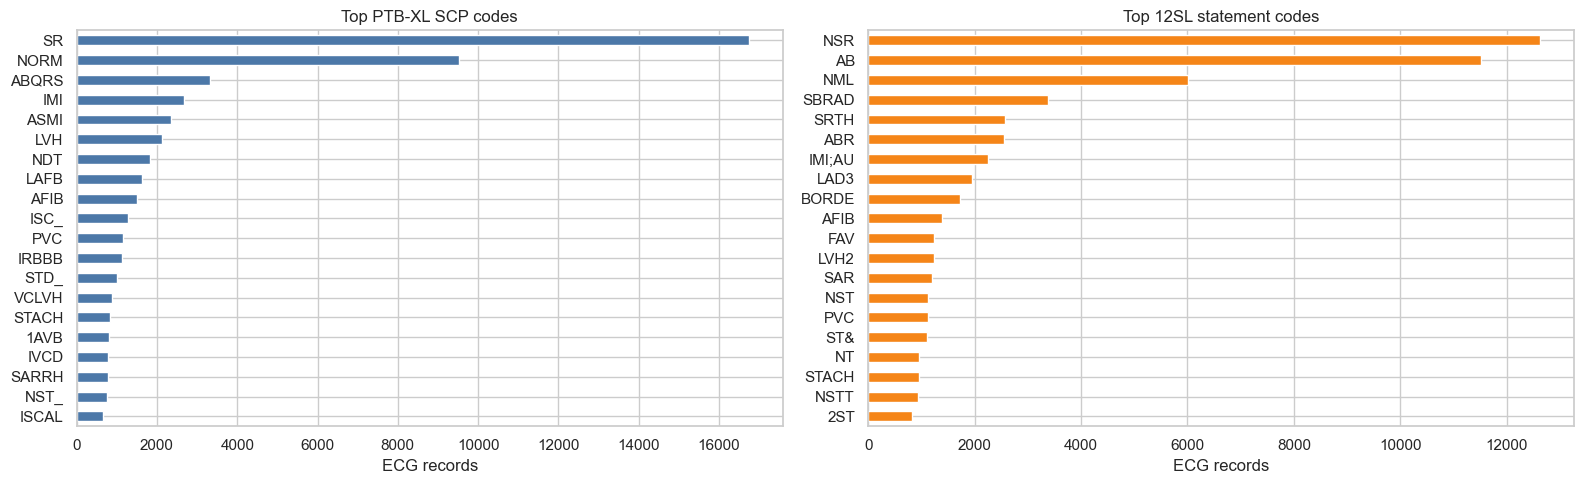

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ptbxl_top = ptbxl_codes["scp_code"].value_counts().head(20).sort_values()
ptbxl_top.plot(kind="barh", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top PTB-XL SCP codes")
axes[0].set_xlabel("ECG records")
axes[0].set_ylabel("")

sl_top = labels_12sl_codes["statement_code"].value_counts().head(20).sort_values()
sl_top.plot(kind="barh", ax=axes[1], color="#F58518")
axes[1].set_title("Top 12SL statement codes")
axes[1].set_xlabel("ECG records")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

,snomed_id,description,records
0,4145513,ECG: sinus rhythm,18978
1,320536,Electrocardiogram abnormal,12864
2,4065279,ECG normal,9514
3,44784217,Cardiac arrhythmia,8011
4,4027255,Structural disorder of heart,8002
5,4185932,Ischemic heart disease,6973
6,4166245,Disorder of cardiac ventricle,5699
7,4064609,EKG: myocardial infarction,5469
8,4329847,Myocardial infarction,5469
9,320425,Heart block,4822


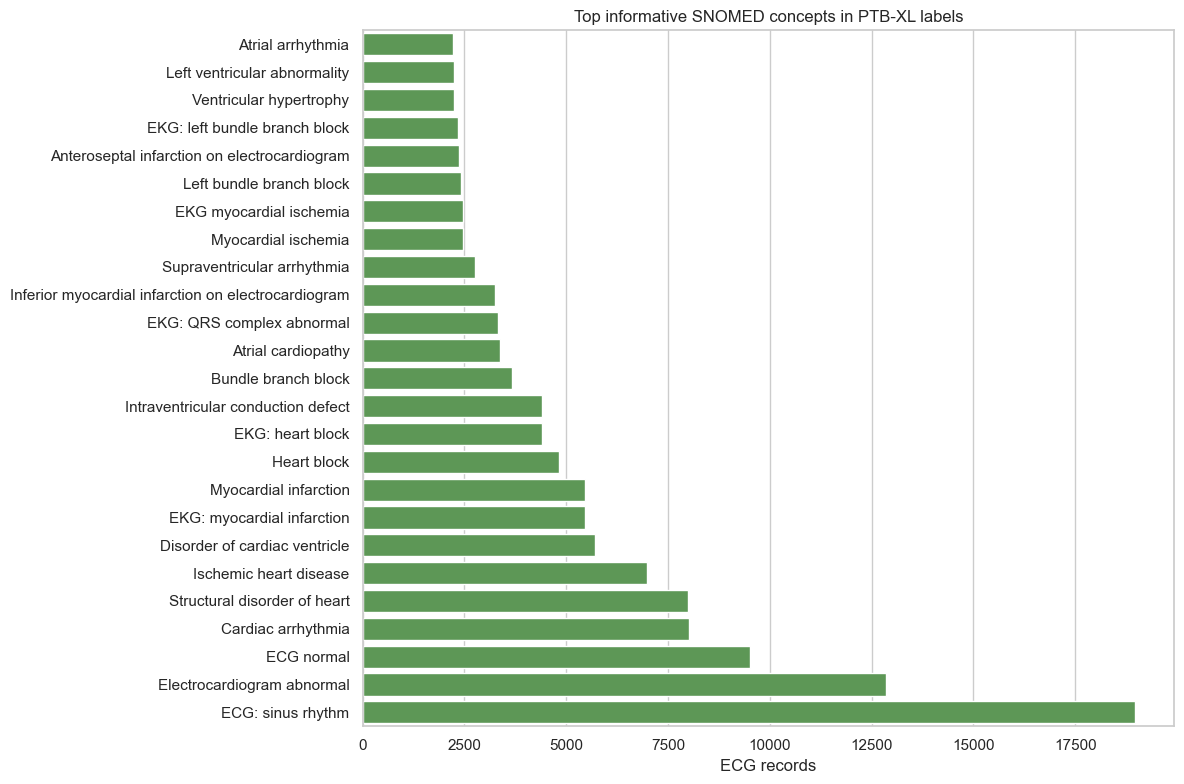

In [6]:
# Most common informative SNOMED concepts in the PTB-XL expanded labels.
ptbxl_snomed_info = ptbxl_snomed[ptbxl_snomed["informative"].fillna(False)].copy()

snomed_top = (
    ptbxl_snomed_info.groupby(["snomed_id", "description"], dropna=False)
    .size()
    .sort_values(ascending=False)
    .head(25)
    .rename("records")
    .reset_index()
)

display(snomed_top)

plt.figure(figsize=(12, 8))
sns.barplot(data=snomed_top.sort_values("records"), x="records", y="description", color="#54A24B")
plt.title("Top informative SNOMED concepts in PTB-XL labels")
plt.xlabel("ECG records")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 4. Arrhythmia-focused target exploration

This section creates a first-pass arrhythmia flag. Treat this as exploratory: before training, confirm the exact clinical target with your project definition.

In [7]:
ARRHYTHMIA_KEYWORDS = re.compile(
    r"arrhythm|fibrillation|flutter|tachy|brady|ectopic|extrasystol|premature|atrioventricular block|av block|heart block|escape rhythm",
    flags=re.IGNORECASE,
)

ARRHYTHMIA_12SL_CODES = {
    "AFIB", "AFLT", "FLUT", "SVARR", "SVTAC", "PSVT", "SARRH", "PACE",
    "SBRAD", "STACH", "SRTH", "SAR", "PAC", "PVC", "PSVC", "PVC2", "VES",
    "BIGU", "TRIGU", "FAV", "VAVB", "AVB", "2AVB", "3AVB", "W2T1", "W3T1",
}

arrhythmia_snomed = snomed[
    snomed["description"].fillna("").str.contains(ARRHYTHMIA_KEYWORDS)
    & snomed["informative"].fillna(False)
].copy()
arrhythmia_snomed_ids = set(arrhythmia_snomed["snomed_id"].astype("int64"))

ptbxl_arrhythmia_ids = set(
    ptbxl_snomed.loc[ptbxl_snomed["snomed_id"].isin(arrhythmia_snomed_ids), "ecg_id"]
)
sl_arrhythmia_ids = set(
    labels_12sl_codes.loc[labels_12sl_codes["statement_code"].isin(ARRHYTHMIA_12SL_CODES), "ecg_id"]
)

all_ecg_ids = pd.Index(sorted(set(labels_ptbxl["ecg_id"]) | set(labels_12sl["ecg_id"])), name="ecg_id")
target = pd.DataFrame(index=all_ecg_ids).reset_index()
target["ptbxl_arrhythmia"] = target["ecg_id"].isin(ptbxl_arrhythmia_ids)
target["12sl_arrhythmia"] = target["ecg_id"].isin(sl_arrhythmia_ids)
target["arrhythmia_candidate"] = target["ptbxl_arrhythmia"] | target["12sl_arrhythmia"]

summary = target[["ptbxl_arrhythmia", "12sl_arrhythmia", "arrhythmia_candidate"]].agg(["sum", "mean"]).T
summary["mean"] = (summary["mean"] * 100).round(2)
summary = summary.rename(columns={"sum": "records", "mean": "percent"})
display(summary)

display(arrhythmia_snomed[["snomed_id", "description", "counts_ptbxl", "counts_12sl"]].sort_values("counts_ptbxl", ascending=False).head(30))

,records,percent
ptbxl_arrhythmia,8516.0,39.07
12sl_arrhythmia,9406.0,43.15
arrhythmia_candidate,11979.0,54.95


,snomed_id,description,counts_ptbxl,counts_12sl
60,44784217,Cardiac arrhythmia,8011,10228
242,320425,Heart block,4822,3687
133,4064457,EKG: heart block,4412,2395
263,4248028,Supraventricular arrhythmia,2766,5914
177,4068155,Atrial arrhythmia,2207,5031
215,313217,Atrial fibrillation,1514,1396
285,4091901,Aberrant premature complexes,1513,2151
83,4089462,Ventricular premature complex,1197,1469
185,4145998,ECG: premature ventricular contractions,1143,1420
224,4007310,Sinus tachycardia,826,957


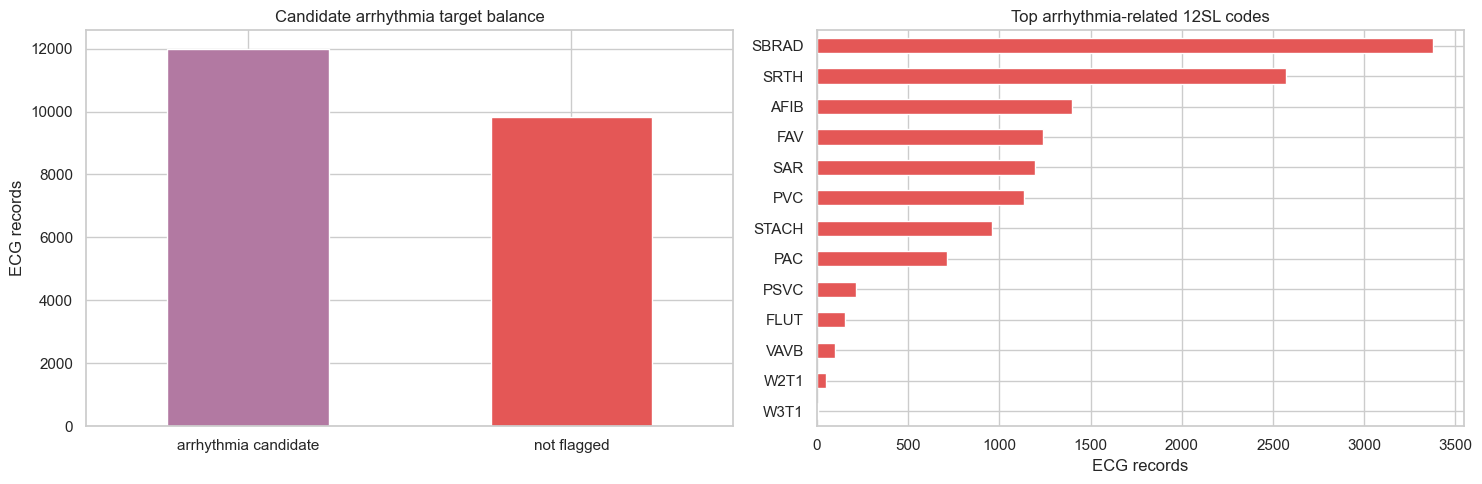

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

target["arrhythmia_candidate"].value_counts().rename(index={False: "not flagged", True: "arrhythmia candidate"}).plot(
    kind="bar", ax=axes[0], color=["#B279A2", "#E45756"]
)
axes[0].set_title("Candidate arrhythmia target balance")
axes[0].set_xlabel("")
axes[0].set_ylabel("ECG records")
axes[0].tick_params(axis="x", rotation=0)

arrhythmia_code_counts = (
    labels_12sl_codes[labels_12sl_codes["statement_code"].isin(ARRHYTHMIA_12SL_CODES)]
    ["statement_code"]
    .value_counts()
    .head(20)
    .sort_values()
)
arrhythmia_code_counts.plot(kind="barh", ax=axes[1], color="#E45756")
axes[1].set_title("Top arrhythmia-related 12SL codes")
axes[1].set_xlabel("ECG records")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 5. Feature quality and separability

Start with global intervals and heart-rate-like fields. These are useful sanity checks for arrhythmia work.

In [9]:
# Use ecgdeli as a compact feature table for exploratory plots, then join the target flag.
ecg_features = features["ecgdeli"].merge(target, on="ecg_id", how="left")

missing = (
    ecg_features.isna().mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .reset_index()
    .rename(columns={"index": "feature"})
)
display(missing.head(30))

candidate_features = [
    "HR__Global", "RR_Mean_Global", "PQ_Int_Global", "PR_Int_Global",
    "QRS_Dur_Global", "QT_Int_Global", "QT_IntFramingham_Global",
    "P_Dur_Global", "T_Dur_Global", "HA__Global",
]
available_features = [col for col in candidate_features if col in ecg_features.columns]
print("Available global features:", available_features)

display(
    ecg_features.groupby("arrhythmia_candidate")[available_features]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T
)

,feature,missing_rate
0,P_Morph_V5,0.392633
1,P_Morph_V3_iqr,0.392633
2,P_Morph_V6_iqr,0.392633
3,P_Morph_aVF,0.392633
4,P_Morph_V6,0.392633
5,P_Morph_I,0.392633
6,P_Morph_V5_iqr,0.392633
7,P_Morph_I_iqr,0.392633
8,P_Morph_aVF_iqr,0.392633
9,P_Morph_III,0.392633


Available global features: ['RR_Mean_Global', 'PQ_Int_Global', 'PR_Int_Global', 'QRS_Dur_Global', 'QT_Int_Global', 'QT_IntFramingham_Global', 'P_Dur_Global', 'T_Dur_Global', 'HA__Global']


arrhythmia_candidate        False         True 
RR_Mean_Global count  9820.000000  11979.000000
               mean    826.378208    861.793221
               std     106.629947    218.500671
               min     382.000000    288.000000
               25%     748.000000    700.000000
...                           ...           ...
HA__Global     min       1.000000      1.000000
               25%       2.000000      2.000000
               50%       2.000000      2.000000
               75%       3.000000      3.000000
               max       6.000000      6.000000

[72 rows x 2 columns]

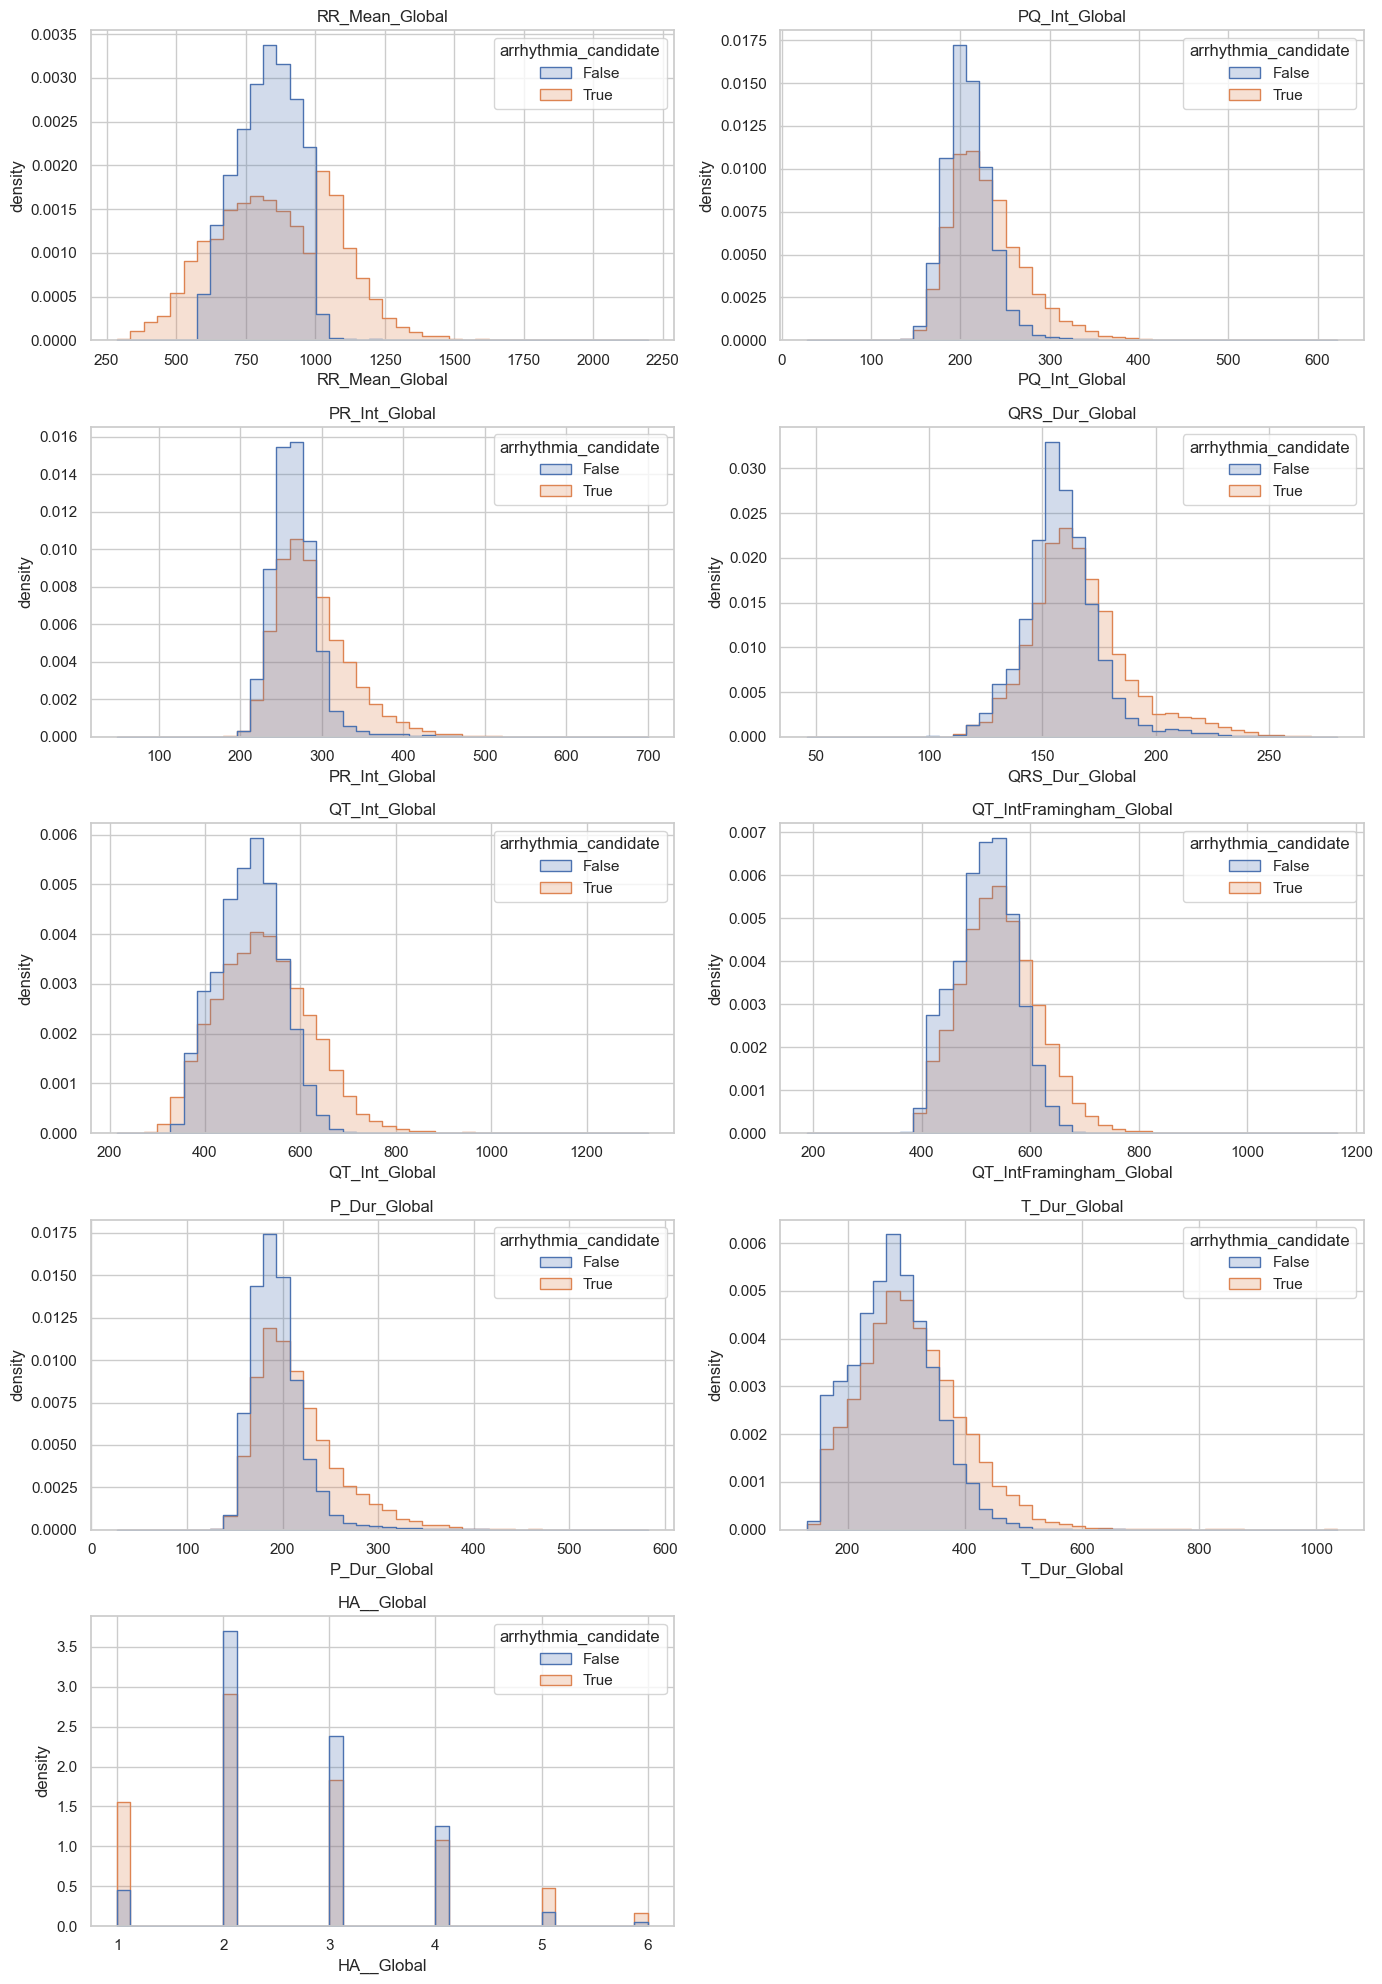

In [10]:
if available_features:
    n_cols = 2
    n_rows = int(np.ceil(len(available_features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, available_features):
        sns.histplot(
            data=ecg_features,
            x=col,
            hue="arrhythmia_candidate",
            bins=40,
            stat="density",
            common_norm=False,
            element="step",
            ax=ax,
        )
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("density")

    for ax in axes[len(available_features):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

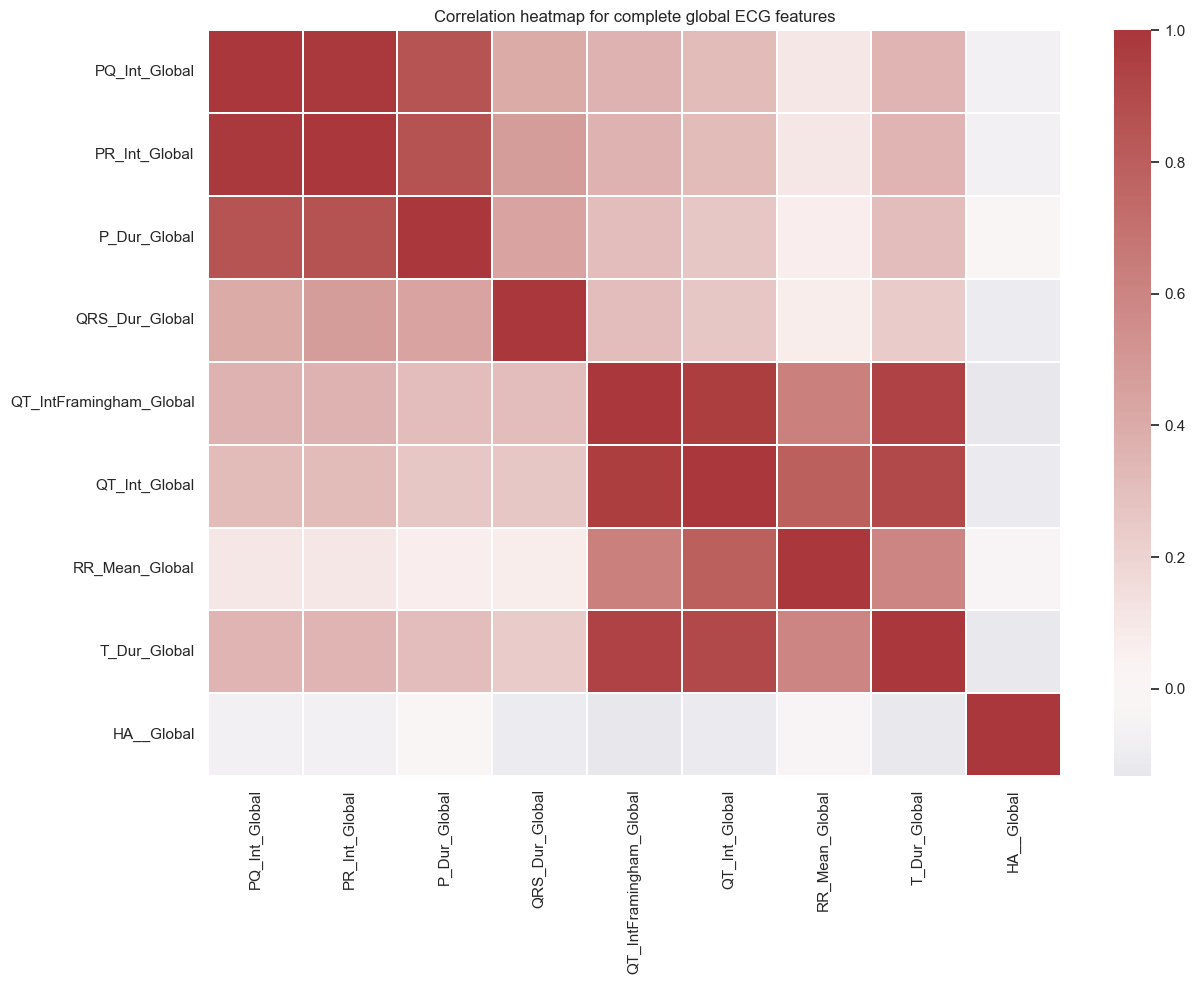

In [11]:
# Correlations among global features, excluding quality/count helper columns.
numeric_cols = ecg_features.select_dtypes(include="number").columns
feature_cols = [
    col for col in numeric_cols
    if col != "ecg_id" and not col.endswith("_count") and not col.endswith("_iqr")
]

# Keep a manageable set: global fields plus the most complete non-global fields.
global_cols = [col for col in feature_cols if "Global" in col or col.endswith("__Global")]
plot_cols = [col for col in global_cols if ecg_features[col].notna().mean() > 0.85][:25]

if len(plot_cols) >= 2:
    plt.figure(figsize=(13, 10))
    corr = ecg_features[plot_cols].corr(numeric_only=True)
    sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.3)
    plt.title("Correlation heatmap for complete global ECG features")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough complete global features for a correlation heatmap.")